<a href="https://colab.research.google.com/github/iammuhammadhassan/AI-Ml-internship-task-next-phase/blob/main/NewsClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets scikit-learn

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
dataset = load_dataset("ag_news")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [ ]:
small_train = dataset["train"].shuffle(seed=42).select(range(20000))
small_test = dataset["test"].shuffle(seed=42).select(range(2000))

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

train_dataset = small_train.map(tokenize_function, batched=True)
test_dataset = small_test.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=1,
    fp16=True,
    logging_steps=500
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()

trainer.train()

end_time = time.time()
print("Training Time (minutes):", (end_time - start_time) / 60)

Step,Training Loss
500,0.375097


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Time (minutes): 4.359975592295329


In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.2763535678386688, 'eval_accuracy': 0.9105, 'eval_f1': 0.9103886122525712, 'eval_runtime': 7.7062, 'eval_samples_per_second': 259.53, 'eval_steps_per_second': 8.175, 'epoch': 1.0}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Downloading Your Model for Local Use

To access your saved model and tokenizer in a local environment like VS Code or Jupyter Notebook, you need to download the `news-classifier` directory from your Colab environment. Here's how:

First, create a zip archive of the `news-classifier` directory:

In [ ]:
# Zip the saved model and tokenizer directory
!zip -r /content/news-classifier.zip /content/news-classifier

  adding: content/news-classifier/ (stored 0%)
  adding: content/news-classifier/training_args.bin (deflated 53%)
  adding: content/news-classifier/model.safetensors (deflated 8%)
  adding: content/news-classifier/tokenizer.json (deflated 71%)
  adding: content/news-classifier/config.json (deflated 53%)
  adding: content/news-classifier/tokenizer_config.json (deflated 42%)


Next, download the created zip file. You can do this by right-clicking the `news-classifier.zip` file in the Colab file browser (left sidebar) and selecting 'Download', or by running the following Python code:

In [ ]:
# Download the zip file
from google.colab import files
files.download('/content/news-classifier.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
trainer.save_model("news-classifier")
tokenizer.save_pretrained("news-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('news-classifier/tokenizer_config.json', 'news-classifier/tokenizer.json')

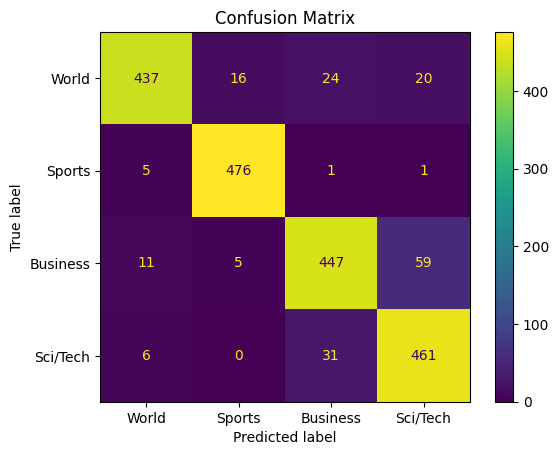

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Labels
labels = ["World", "Sports", "Business", "Sci/Tech"]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
from transformers import pipeline

classifier = pipeline("text-classification", model="news-classifier")

labels = ["World", "Sports", "Business", "Sci/Tech"]

def predict(text):
    result = classifier(text)[0]
    return f"{labels[int(result['label'].split('_')[-1])]} (confidence: {round(result['score'], 3)})"

gr.Interface(fn=predict, inputs="text", outputs="text").launch()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4971ef093ec887592b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
    # 1. Configure Git with your credentials
!git config --global user.email "iam.muhammad.hassan0@gmail.com"
!git config --global user.name "iammuhammadhassan"

# 2. Clone your GitHub repository
!git clone https://github.com/iammuhammadhassan/AI-Ml-internship-task-next-phase.git

# 3. Navigate into the cloned repository
%cd AI-Ml-internship-task-next-phase

# 4. Add all files from your current Colab project
!git add .

# 5. Commit your changes with a meaningful message
!git commit -m "News Classifier project"

# 6. Push to GitHub using a Personal Access Token for authentication
# IMPORTANT: Replace <YOUR_GITHUB_USERNAME> and <YOUR_PERSONAL_ACCESS_TOKEN>
# You can generate a PAT in your GitHub settings -> Developer settings -> Personal access tokens -> Tokens (classic)
!git push https://<>:<YOUR_PERSONAL_ACCESS_TOKEN>@github.com/iammuhammadhassan/AI-Ml-internship-task-next-phase.git

Cloning into 'AI-Ml-internship-task-next-phase'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 8 (delta 1), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 41.01 KiB | 1.32 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/AI-Ml-internship-task-next-phase/AI-Ml-internship-task-next-phase/AI-Ml-internship-task-next-phase/AI-Ml-internship-task-next-phase
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
/bin/bash: line 1: YOUR_GITHUB_USERNAME: No such file or directory
